# ASME Diameters Design for Strength

This is the full notebook that solves (1) the force and moment balance for every shaft, (2) the ASME design equation for every element.

In [2]:
%%javascript
require(["notebook/js/outputarea"],function(oa) {oa.OutputArea.auto_scroll_threshold=-1;console.log("Setting auto_scroll_threshold to -1");});

<IPython.core.display.Javascript object>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

sb.set()
plt.rcParams['figure.dpi']=120
plt.rcParams['savefig.dpi']=120

In [4]:
class MachineElement:
    """
    Defines a machine element in shaft design
    
    Parameters:
    
    torque_Nm -- Torque experienced by the machine element.
    moment_Nm -- Moment experienced by the machine element.
    scf_l -- Stress concentration factor left of the element
    scf_m -- Stress concentration factor in the middle of the element.
    scf_r -- Stress concentration factor right of the element.
    sy_MPa -- Yield strength of the element
    su_MPa -- Ultimate strength of the element.
    sn_MPa -- Endurance strength of the element.
    initdia_mm -- Initial guess for the diameter.
    
    The calculations for the minimum diameter for the left, middle, and right of the
    machine element is stored as an attribute of the object.
    
    How to use:
        (1) Solve the moments and torque associated with free-body diagram of the object.
        (2) Declare the associated stress concentration factors.
        (3) Performs 10 iterations of the ASME design for strength equation to get the minimum diameter.
        (4) You may print the attributes of the object to view the diameter.
        
    NOTE: 99% reliability is implicitly assumed, with a safety factor N = 3.

    """
    def __init__(self, 
                 torque_Nm = 0, 
                 moment_Nm = 0, 
                 scf_l = 1, 
                 scf_m = 1, 
                 scf_r = 1, 
                 sy_MPa = 1960, 
                 su_MPa = 1610,
                 sn_MPa = 455,
                 initdia_mm = 25,
                 name_str = "Nameless",
                 datum_str = "Shaft 1",
                 x_mm = 0.0,
                 Fx_N = 0.0,
                 Fy_N = 0.0):
        self.torque_Nm = torque_Nm
        self.torque_Nmm = self.torque_Nm * 10**(3)
        self.moment_Nm = moment_Nm
        self.xmoment_Nm = 0.0
        self.ymoment_Nm = 0.0
        self.moment_Nmm = self.moment_Nm * 10**(3)
        # The reliability factor is implicitly assumed here.
        self.reliability_factor = 0.81 
        # The factor of safety is implicitly assumed here.
        self.N = 3   
        self.scf_l = scf_l
        self.scf_m = scf_m
        self.scf_r = scf_r
        self.sy_MPa = sy_MPa
        self.su_MPa = su_MPa
        self.sn_MPa = sn_MPa
        self.datum_str = datum_str
        self.x_mm = x_mm
        self.Fx_N = Fx_N
        self.Fy_N = Fy_N
        self.F_net = (Fx_N ** 2 + Fy_N ** 2)**0.5
        self.name_str = name_str
        def mindia(K,
                   dia_mm,
                   N = self.N,
                   pi = 3.1415926358979,
                   M = self.moment_Nm,
                   T = self.torque_Nm,
                   sy = self.sy_MPa * 10**6):
            """
            Procedure, calculates minimum diameter based on ASME equation.
            """
            if dia_mm <= 7.62:
                cs = 1
            elif 7.62 <= dia_mm <= 50:
                cs = (dia_mm/7.62)**(-0.11)
            else:
                cs = 0.859 - 0.000837 * self.dia_mm
            sn = self.sn_MPa * self.reliability_factor * cs * 10**6
            return cs, ((32*N/pi)*((K*M/sn)**2+(3/4)*(T/sy)**2)**0.5)**(1/3)*(10**3)
        
        for i in range(1,10):
            cs1, initdia_mm = mindia(self.scf_l, initdia_mm)
        cs1, self.ldia_mm = mindia(self.scf_l, initdia_mm)
        
        for i in range(1,10):
            cs1, initdia_mm = mindia(self.scf_m, initdia_mm)
        cs1, self.mdia_mm = mindia(self.scf_m, initdia_mm)
        
        for i in range(1,10):
            cs1, initdia_mm = mindia(self.scf_r, initdia_mm)
        cs1, self.rdia_mm = mindia(self.scf_r, initdia_mm)

def PrintSelf(ME):
    """
    Procedure, prints init.
    """
    print("-----------")
    print(ME.name_str)
    print("-----------")
    attrs = vars(ME)
    print(''.join("%s: %s \n" % item for item in attrs.items()))


    
def PrintMEList(ordered_list):
    """
    Procedure, prints attributes in ordered list of objects
    """
    for obj in ordered_list:
        PrintSelf(obj)
    
def PrintShaftResults(ordered_list):
    """
    Procedure. Prints results for shaft design.
    """
    for obj in ordered_list:
        print("Minimum diameter in mm as per ASME design equations for", obj.name_str)
        print("Left point: \t ", obj.ldia_mm, " mm")
        print("Middle point: \t ", obj.mdia_mm, " mm")
        print("Right point: \t ", obj.rdia_mm, " mm")

def force_solver_1D(known_list, unknown_list, axis_str = "x"):
    """
    Given a list of MachineElement objects, solves a statically determinate shaft in one dimension
    """
    
    if len(unknown_list) > 2:
        return "This is statically indeterminate!"
    
    x_mm_list = []
    
    for machine_element in unknown_list:
        x_mm_list += [machine_element.x_mm]
    
    x_mm_np = np.array(x_mm_list)
    
    B_list = [0, 0]
    
    for machine_element in known_list:
        if axis_str == "x":
            B_list[0] -= machine_element.Fx_N
            B_list[1] -= machine_element.Fx_N * machine_element.x_mm
        if axis_str == "y":
            B_list[0] -= machine_element.Fy_N
            B_list[1] -= machine_element.Fy_N * machine_element.x_mm
    A = np.array([np.ones(2), x_mm_np])
    B = np.array(B_list)
    X = np.linalg.solve(A,B)
    print("[Unknown force for first, unknown force for second]", X)
    if axis_str == "x":
        unknown_list[0].Fx_N = X[0]
        unknown_list[1].Fx_N = X[1]
    elif axis_str == "y":
        unknown_list[0].Fy_N = X[0]
        unknown_list[1].Fy_N = X[1]   
    else:
        print("Error, axis is ill-defined.")
    
def shaft_bmd(order_list, name_str = "Nameless"):
    
    horizontal_list = []

    for obj in order_list:
        horizontal_list += [obj.x_mm]

    x_values = [0]    
    y_values = [0]

    value = 0
    for index in range(1,len(order_list)):
        g_int = int(0)
        while g_int < index:
            value += order_list[g_int].Fx_N * (order_list[index].x_mm - order_list[index - 1].x_mm)
            g_int += 1
        x_values += [value]

    value = 0
    for index in range(1,len(order_list)):
        g_int = int(0)
        while g_int < index:
            value += order_list[g_int].Fy_N * (order_list[index].x_mm - order_list[index - 1].x_mm)
            g_int += 1
        y_values += [value]

    value = 0
    print(
    """The bending moments in the x-axis are: \n"""
    )
    print(x_values)
    print()
    print(
    """The bending moments in the y-axis are: \n"""
    )   
    print(y_values)
    
    print()
    for obj in order_list:
        print("X-axis Force at ", obj.name_str ," = ",obj.Fx_N)
    print()
    for obj in order_list:
        print("Y-axis Force at ", obj.name_str ," = ",obj.Fy_N)
    print()
    
    for index in range(0, len(order_list)):
        bmd = (x_values[index] ** 2 + y_values[index] ** 2)**0.5
        print("Net bending moment (in Nm) at ", order_list[index].name_str ," = \t", bmd * 10**(-3))
        print("xz  bending moment (in Nm) at ", order_list[index].name_str ," = \t", x_values[index] * 10**(-3))
        print("yz  bending moment (in Nm) at ", order_list[index].name_str ," = \t", y_values[index] * 10**(-3))
        order_list[index].moment_Nm = bmd * 10**(-3)
        order_list[index].xmoment_Nm = x_values[index] * 10**(-3)
        order_list[index].ymoment_Nm = y_values[index] * 10**(-3)
        
    f, axes = plt.subplots(1,1, figsize=(10,6))
    plt.plot(horizontal_list, x_values, linewidth=1, marker="x", color="k")
    plt.title("Bending moment diagram for x-z, " + name_str, fontsize=10)
    plt.xlabel("Shaft axis (mm)", fontsize=10)
    plt.ylabel("Bending moment (Nmm)", fontsize=10)
    plt.tick_params(axis='both', labelsize=10)
    plt.show()
    
    f, axes = plt.subplots(1,1, figsize=(10,6))
    plt.plot(horizontal_list, y_values, linewidth=1, marker="x", color="k")
    plt.title("Bending moment diagram for y-z, " + name_str, fontsize=10)
    plt.xlabel("Shaft axis (mm)", fontsize=10)
    plt.ylabel("Bending moment (Nmm)", fontsize=10)
    plt.tick_params(axis='both', labelsize=10)
    plt.show()
    
    T_values = []
    T_horizontal_list = []
    for index in range(0,len(order_list)):
        if order_list[index].torque_Nm > order_list[index-1].torque_Nm and index != 0:
            T_horizontal_list += [order_list[index].x_mm]
            T_values += [order_list[index-1].torque_Nm]
        if order_list[index].torque_Nm < order_list[index-1].torque_Nm and index != 0:
            T_horizontal_list += [order_list[index-1].x_mm]
            T_values += [order_list[index].torque_Nm]
        T_horizontal_list += [order_list[index].x_mm]
        T_values += [order_list[index].torque_Nm]
        print("Net torque (in Nm) at\t", order_list[index].name_str ," = \t", order_list[index].torque_Nm)
        
    f, axes = plt.subplots(1,1, figsize=(10,6))
    plt.plot(T_horizontal_list, T_values, linewidth=1, marker="x", color="k")
    plt.title("Torque diagram for z, " + name_str, fontsize=10)
    plt.xlabel("Shaft axis (mm)", fontsize=10)
    plt.ylabel("Torque (Nm)", fontsize=10)
    plt.tick_params(axis='both', labelsize=10)
    plt.show()

# Motor-Coupling-Belt

In [5]:
bearing1 =  MachineElement( 
            torque_Nm = 3.00,           # Torque experienced by the machine element
            moment_Nm = 0,               # Moment experienced by the machine element
            scf_l = 3,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 1.5,                   # Stress concentration of the immediate right element
            sy_MPa = 690,               # Yield strength
            su_MPa = 621,               # Ultimate strength
            sn_MPa = 250,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 10,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Bearing 1 - Motor-Coupling-Belt",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 0,                # Force in vertical direction, from the floor to the roller.
            x_mm = 145.5)                    # Relative position of element. x_mm = 0 for the left most.

belt_driver =  MachineElement( 
            torque_Nm = 3.00,           # Torque experienced by the machine element
            moment_Nm = 5.105743259810127,  # Moment experienced by the machine element
            scf_l = 1.5,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 3,                   # Stress concentration of the immediate right element
            sy_MPa = 690,               # Yield strength
            su_MPa = 621,               # Ultimate strength
            sn_MPa = 250,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Belt Driving Sheave - Motor-Coupling-Belt",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 135.42,                # Force in vertical direction, from the floor to the roller.
            x_mm = 207.65)                    # Relative position of element. x_mm = 0 for the left most.

bearing2 =  MachineElement( 
            torque_Nm = 0,           # Torque experienced by the machine element
            moment_Nm = 0,               # Moment experienced by the machine element
            scf_l = 1.5,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 3,                   # Stress concentration of the immediate right element
            sy_MPa = 690,               # Yield strength
            su_MPa = 621,               # Ultimate strength
            sn_MPa = 250,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Bearing 2 - Motor-Coupling-Belt",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 0,                # Force in vertical direction, from the floor to the roller.
            x_mm = 303.5)                    # Relative position of element. x_mm = 0 for the left most.

In [6]:
# The code will automatically solve and update the force in the y direction Fy_N 
# of the element with the solved force.
force_solver_1D(known_list = [belt_driver],    # Put elements with unknown forces here
                unknown_list = [bearing1, bearing2],       # Put elements with known forces here
                axis_str = "y")                            # State the axis of solution.

[Unknown force for first, unknown force for second] [-82.15194304 -53.26805696]


The bending moments in the x-axis are: 

[0, 0.0, 0.0]

The bending moments in the y-axis are: 

[0, -5105.743259810127, 0.0]

X-axis Force at  Bearing 1 - Motor-Coupling-Belt  =  0
X-axis Force at  Belt Driving Sheave - Motor-Coupling-Belt  =  0
X-axis Force at  Bearing 2 - Motor-Coupling-Belt  =  0

Y-axis Force at  Bearing 1 - Motor-Coupling-Belt  =  -82.15194303797468
Y-axis Force at  Belt Driving Sheave - Motor-Coupling-Belt  =  135.42
Y-axis Force at  Bearing 2 - Motor-Coupling-Belt  =  -53.26805696202532

Net bending moment (in Nm) at  Bearing 1 - Motor-Coupling-Belt  = 	 0.0
xz  bending moment (in Nm) at  Bearing 1 - Motor-Coupling-Belt  = 	 0.0
yz  bending moment (in Nm) at  Bearing 1 - Motor-Coupling-Belt  = 	 0.0
Net bending moment (in Nm) at  Belt Driving Sheave - Motor-Coupling-Belt  = 	 5.105743259810127
xz  bending moment (in Nm) at  Belt Driving Sheave - Motor-Coupling-Belt  = 	 0.0
yz  bending moment (in Nm) at  Belt Driving Sheave - Motor-Coupling-Belt  = 	 -5.1057432

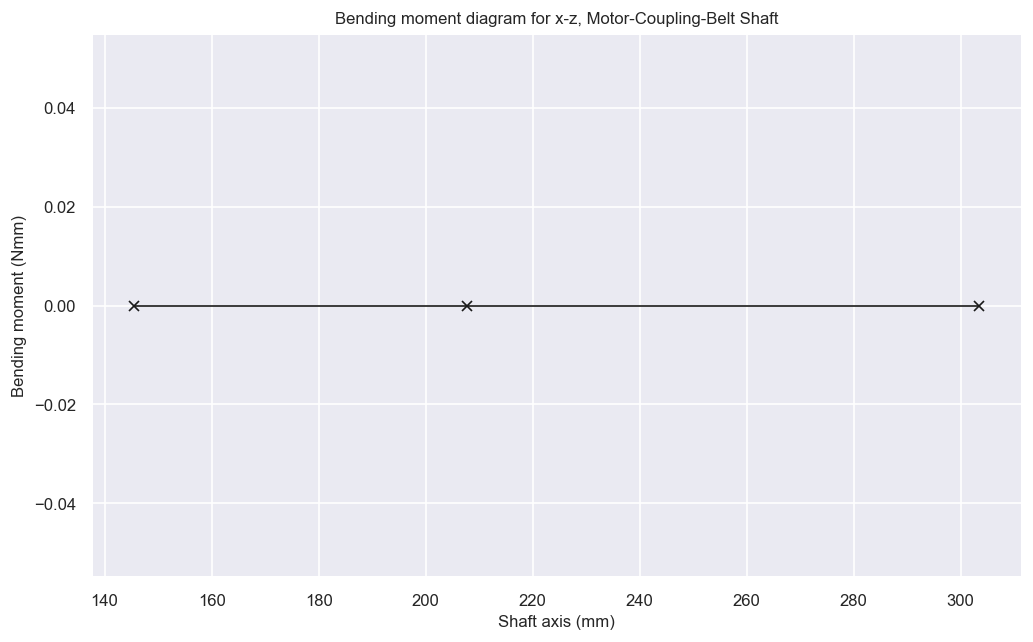

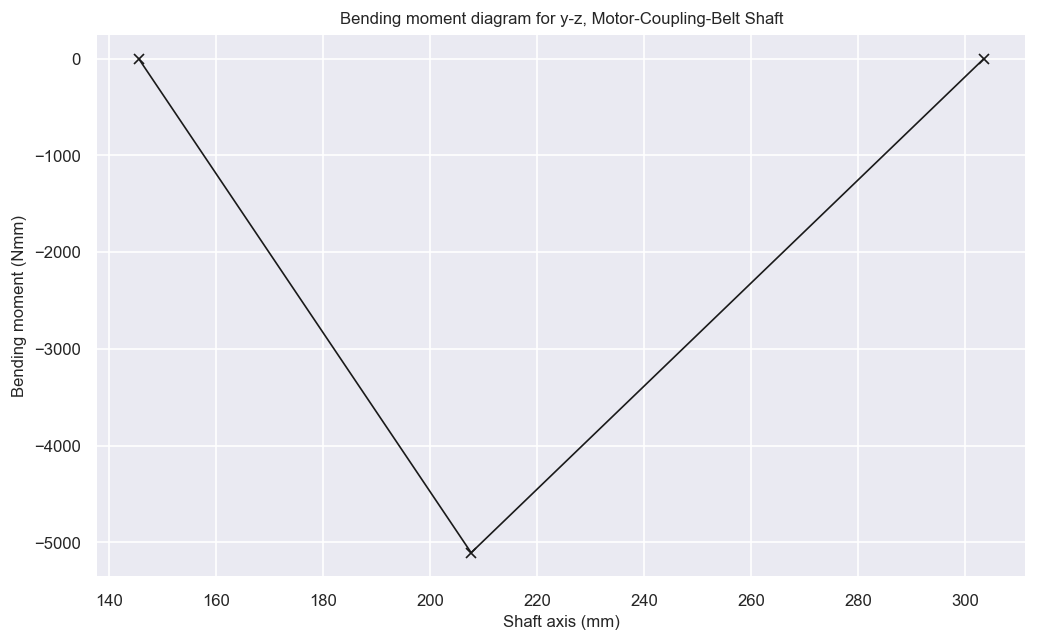

Net torque (in Nm) at	 Bearing 1 - Motor-Coupling-Belt  = 	 3.0
Net torque (in Nm) at	 Belt Driving Sheave - Motor-Coupling-Belt  = 	 3.0
Net torque (in Nm) at	 Bearing 2 - Motor-Coupling-Belt  = 	 0


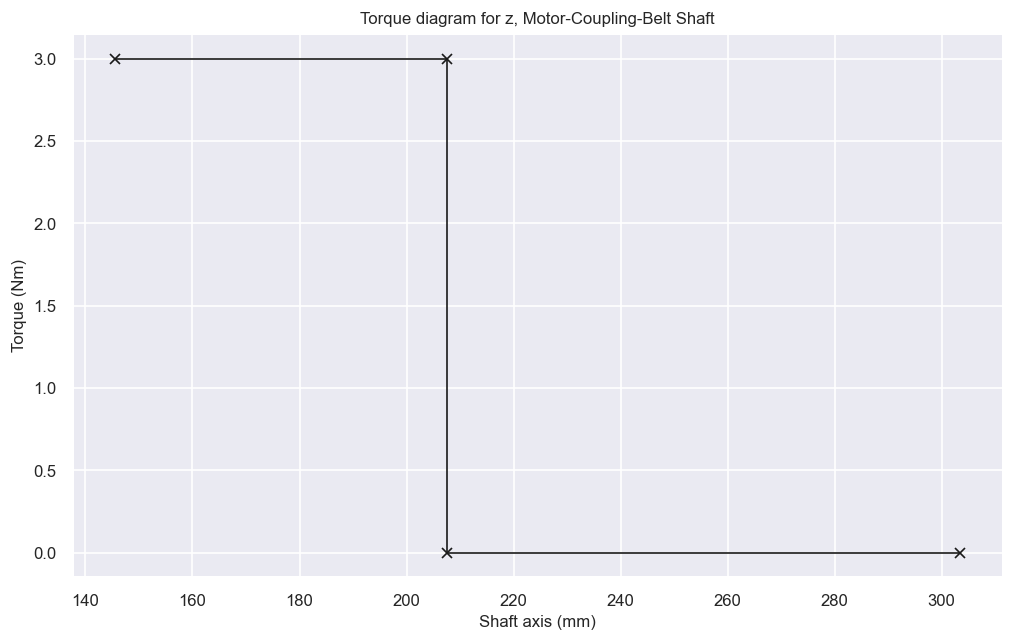

In [7]:
shaft_bmd([bearing1, belt_driver, bearing2], "Motor-Coupling-Belt Shaft")

In [8]:
PrintShaftResults([bearing1, belt_driver, bearing2])

Minimum diameter in mm as per ASME design equations for Bearing 1 - Motor-Coupling-Belt
Left point: 	  4.86378892496282  mm
Middle point: 	  4.86378892496282  mm
Right point: 	  4.86378892496282  mm
Minimum diameter in mm as per ASME design equations for Belt Driving Sheave - Motor-Coupling-Belt
Left point: 	  10.639669343077975  mm
Middle point: 	  9.266084641912709  mm
Right point: 	  13.507217268853138  mm
Minimum diameter in mm as per ASME design equations for Bearing 2 - Motor-Coupling-Belt
Left point: 	  0.0  mm
Middle point: 	  0.0  mm
Right point: 	  0.0  mm


In [9]:
PrintMEList([bearing1, belt_driver, bearing2])

-----------
Bearing 1 - Motor-Coupling-Belt
-----------
torque_Nm: 3.0 
torque_Nmm: 3000.0 
moment_Nm: 0.0 
xmoment_Nm: 0.0 
ymoment_Nm: 0.0 
moment_Nmm: 0 
reliability_factor: 0.81 
N: 3 
scf_l: 3 
scf_m: 1 
scf_r: 1.5 
sy_MPa: 690 
su_MPa: 621 
sn_MPa: 250 
datum_str: Shaft 1 
x_mm: 145.5 
Fx_N: 0 
Fy_N: -82.15194303797468 
F_net: 0.0 
name_str: Bearing 1 - Motor-Coupling-Belt 
ldia_mm: 4.86378892496282 
mdia_mm: 4.86378892496282 
rdia_mm: 4.86378892496282 

-----------
Belt Driving Sheave - Motor-Coupling-Belt
-----------
torque_Nm: 3.0 
torque_Nmm: 3000.0 
moment_Nm: 5.105743259810127 
xmoment_Nm: 0.0 
ymoment_Nm: -5.105743259810127 
moment_Nmm: 5105.743259810127 
reliability_factor: 0.81 
N: 3 
scf_l: 1.5 
scf_m: 1 
scf_r: 3 
sy_MPa: 690 
su_MPa: 621 
sn_MPa: 250 
datum_str: Shaft 1 
x_mm: 207.65 
Fx_N: 0 
Fy_N: 135.42 
F_net: 135.42 
name_str: Belt Driving Sheave - Motor-Coupling-Belt 
ldia_mm: 10.639669343077975 
mdia_mm: 9.266084641912709 
rdia_mm: 13.507217268853138 

--------

# Belt-Chain (Shaft 2)

In [10]:
bearing4 =  MachineElement( 
            torque_Nm = 0,           # Torque experienced by machine element
            moment_Nm = 0,               # Moment experienced by machine element
            scf_l = 3,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 1.5,                   # Stress concentration of the immediate right element
            sy_MPa = 690,               # Yield strength
            su_MPa = 621,               # Ultimate strength
            sn_MPa = 250,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Bearing 4 - Belt-Chain",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 0,                # Force in vertical direction, from the floor to the roller.
            x_mm = 0.0)                    # Relative position of element. x_mm = 0 for the left most.

chain_driver =  MachineElement( 
            torque_Nm = 8.4083,           # Torque experienced by machine element
            moment_Nm = 6.974270400000001,                 # Moment experienced by machine element
            scf_l = 3,                    # Stress concentration of the immediate left element
            scf_m = 1,                    # Stress concentration of the element (middle)
            scf_r = 1.5,                    # Stress concentration of the immediate right element
            sy_MPa = 690,                 # Yield strength
            su_MPa = 621,                 # Ultimate strength
            sn_MPa = 250,                 # Endurance strength (nominal), actual endurance strength will be
                                          # automatically calculated as part of the class.
            initdia_mm = 30,              # Initial diameter for iteration with size factor. Size factor
                                          # is automatically calculated as part of the class.
            name_str = "Chain Driving Sprocket - Belt-Chain",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 367.07,                # Force in vertical direction, from the floor to the roller.
            x_mm = 32.0)                    # Relative position of element. x_mm = 0 for the left most.

belt_driven =  MachineElement( 
            torque_Nm = 8.4083,           # Torque experienced by machine element
            moment_Nm = 1.8294906750000028,                 # Moment experienced by machine element
            scf_l = 1.5,                    # Stress concentration of the immediate left element
            scf_m = 1,                    # Stress concentration of the element (middle)
            scf_r = 3,                    # Stress concentration of the immediate right element
            sy_MPa = 690,                 # Yield strength
            su_MPa = 621,                 # Ultimate strength
            sn_MPa = 250,                 # Endurance strength (nominal), actual endurance strength will be
                                          # automatically calculated as part of the class.
            initdia_mm = 30,              # Initial diameter for iteration with size factor. Size factor
                                          # is automatically calculated as part of the class.
            name_str = "Belt Driven Sheave - Belt-Chain",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = -135.42,                # Force in vertical direction, from the floor to the roller.
            x_mm = 66.5)                    # Relative position of element. x_mm = 0 for the left most.

bearing3 =  MachineElement( 
            torque_Nm = 0,           # Torque experienced by machine element
            moment_Nm = 0,               # Moment experienced by machine element
            scf_l = 1.5,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 3,                   # Stress concentration of the immediate right element
            sy_MPa = 690,               # Yield strength
            su_MPa = 621,               # Ultimate strength
            sn_MPa = 250,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Bearing 3 - Belt-Chain",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 0,                # Force in vertical direction, from the floor to the roller.
            x_mm = 200.0)                    # Relative position of element. x_mm = 0 for the left most.

In [11]:
# The code will automatically solve and update the force in the y direction Fy_N 
# of the element with the solved force.
force_solver_1D(known_list = [chain_driver, belt_driven],    # Put elements with unknown forces here
                unknown_list = [bearing4, bearing3],       # Put elements with known forces here
                axis_str = "y")                            # State the axis of solution.

[Unknown force for first, unknown force for second] [-217.94595  -13.70405]


The bending moments in the x-axis are: 

[0, 0.0, 0.0, 0.0]

The bending moments in the y-axis are: 

[0, -6974.2704, -1829.4906750000027, 0.0]

X-axis Force at  Bearing 4 - Belt-Chain  =  0
X-axis Force at  Chain Driving Sprocket - Belt-Chain  =  0
X-axis Force at  Belt Driven Sheave - Belt-Chain  =  0
X-axis Force at  Bearing 3 - Belt-Chain  =  0

Y-axis Force at  Bearing 4 - Belt-Chain  =  -217.94595
Y-axis Force at  Chain Driving Sprocket - Belt-Chain  =  367.07
Y-axis Force at  Belt Driven Sheave - Belt-Chain  =  -135.42
Y-axis Force at  Bearing 3 - Belt-Chain  =  -13.704050000000006

Net bending moment (in Nm) at  Bearing 4 - Belt-Chain  = 	 0.0
xz  bending moment (in Nm) at  Bearing 4 - Belt-Chain  = 	 0.0
yz  bending moment (in Nm) at  Bearing 4 - Belt-Chain  = 	 0.0
Net bending moment (in Nm) at  Chain Driving Sprocket - Belt-Chain  = 	 6.974270400000001
xz  bending moment (in Nm) at  Chain Driving Sprocket - Belt-Chain  = 	 0.0
yz  bending moment (in Nm) at  Chain Driving Spr

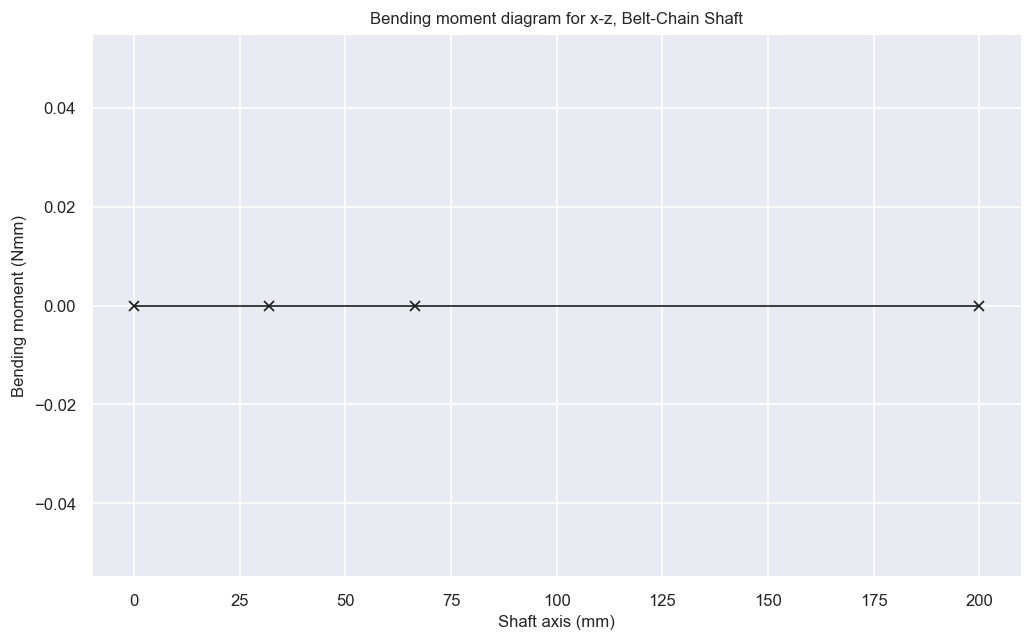

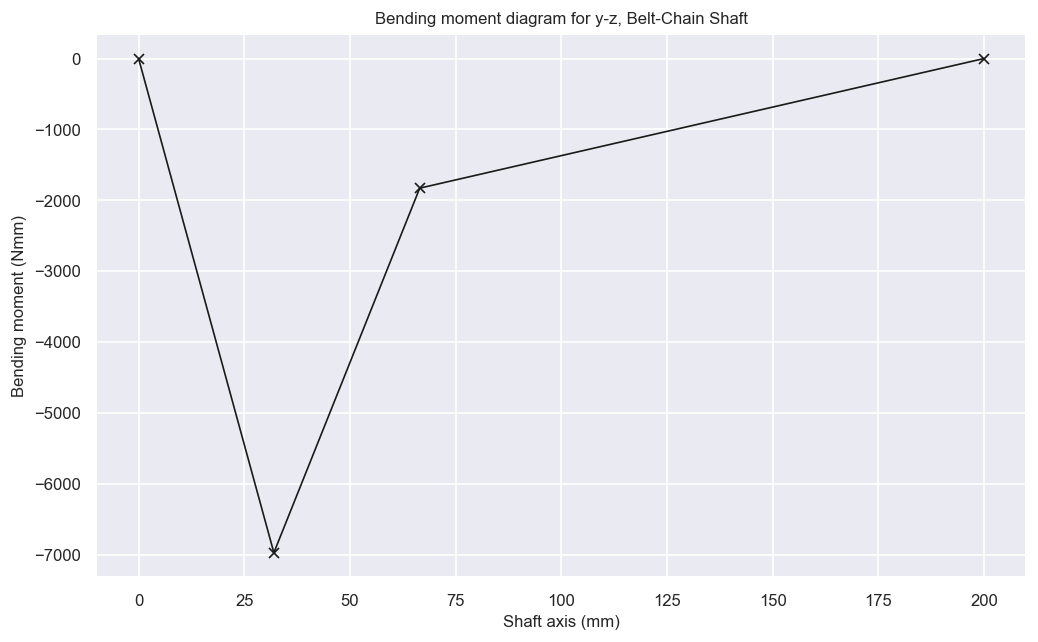

Net torque (in Nm) at	 Bearing 4 - Belt-Chain  = 	 0
Net torque (in Nm) at	 Chain Driving Sprocket - Belt-Chain  = 	 8.4083
Net torque (in Nm) at	 Belt Driven Sheave - Belt-Chain  = 	 8.4083
Net torque (in Nm) at	 Bearing 3 - Belt-Chain  = 	 0


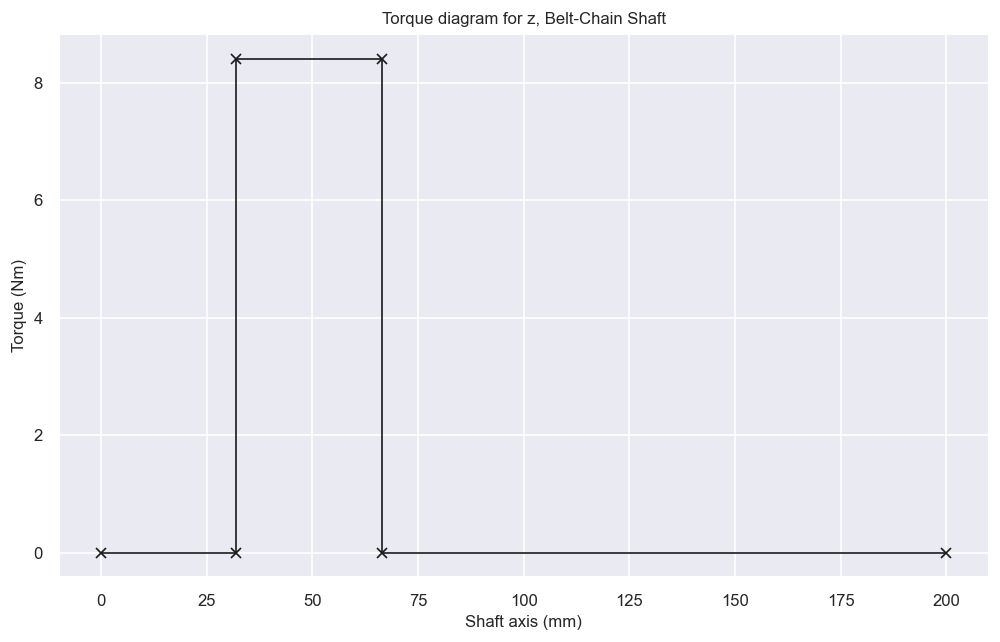

In [12]:
shaft_bmd([bearing4, chain_driver, belt_driven, bearing3], "Belt-Chain Shaft")

In [13]:
PrintShaftResults([bearing4, chain_driver, bearing3, belt_driven])

Minimum diameter in mm as per ASME design equations for Bearing 4 - Belt-Chain
Left point: 	  0.0  mm
Middle point: 	  0.0  mm
Right point: 	  0.0  mm
Minimum diameter in mm as per ASME design equations for Chain Driving Sprocket - Belt-Chain
Left point: 	  15.063941208684485  mm
Middle point: 	  10.43479352036433  mm
Right point: 	  11.909511070960251  mm
Minimum diameter in mm as per ASME design equations for Bearing 3 - Belt-Chain
Left point: 	  0.0  mm
Middle point: 	  0.0  mm
Right point: 	  0.0  mm
Minimum diameter in mm as per ASME design equations for Belt Driven Sheave - Belt-Chain
Left point: 	  8.07722729858452  mm
Middle point: 	  7.515622785149389  mm
Right point: 	  9.688712984962859  mm


# Chain-Gear (Shaft 3)

In [14]:
gear_driver =  MachineElement( 
            torque_Nm = 43.66,           # Torque experienced by machine element
            moment_Nm = 0,# Moment experienced by machine element
            scf_l = 3,                    # Stress concentration of the immediate left element
            scf_m = 1,                    # Stress concentration of the element (middle)
            scf_r = 1.5,                    # Stress concentration of the immediate right element
            sy_MPa = 690,                 # Yield strength
            su_MPa = 621,                 # Ultimate strength
            sn_MPa = 250,                 # Endurance strength (nominal), actual endurance strength will be
                                          # automatically calculated as part of the class.
            initdia_mm = 30,              # Initial diameter for iteration with size factor. Size factor
                                          # is automatically calculated as part of the class.
            name_str = "Driving gear - Chain-Gear",         
            Fx_N = -1122,                 # Force parallel to the working surface
            Fy_N = -408.5,                # Force in vertical direction, from the floor to the roller.
            x_mm = 18.0)                    # Relative position of element. x_mm = 0 for the left most.


bearing6 =  MachineElement( 
            torque_Nm = 43.66,           # Torque experienced by machine element
            moment_Nm = 46.567963840498756,               # Moment experienced by machine element
            scf_l = 1.5,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 1.5,                   # Stress concentration of the immediate right element
            sy_MPa = 690,               # Yield strength
            su_MPa = 621,               # Ultimate strength
            sn_MPa = 250,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Bearing 6 - Chain-Gear",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 0,                # Force in vertical direction, from the floor to the roller.
            x_mm = 57)                    # Relative position of element. x_mm = 0 for the left most.

chain_driven =  MachineElement( 
            torque_Nm = 43.66,           # Torque experienced by machine element
            moment_Nm = 31.044703372388984,                 # Moment experienced by machine element
            scf_l = 1.5,                    # Stress concentration of the immediate left element
            scf_m = 1,                    # Stress concentration of the element (middle)
            scf_r = 1.5,                    # Stress concentration of the immediate right element
            sy_MPa = 690,                 # Yield strength
            su_MPa = 621,                 # Ultimate strength
            sn_MPa = 250,                 # Endurance strength (nominal), actual endurance strength will be
                                          # automatically calculated as part of the class.
            initdia_mm = 30,              # Initial diameter for iteration with size factor. Size factor
                                          # is automatically calculated as part of the class.
            name_str = "Chain Driven Sprocket - Chain-Gear",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = -367.07,                # Force in vertical direction, from the floor to the roller.
            x_mm = 100.0)                    # Relative position of element. x_mm = 0 for the left most.


bearing5 =  MachineElement( 
            torque_Nm = 0,           # Torque experienced by machine element
            moment_Nm = 0,               # Moment experienced by machine element
            scf_l = 1.5,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 3,                   # Stress concentration of the immediate right element
            sy_MPa = 690,               # Yield strength
            su_MPa = 621,               # Ultimate strength
            sn_MPa = 250,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Bearing 5 - Chain-Gear",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 0,                # Force in vertical direction, from the floor to the roller.
            x_mm = 150)                    # Relative position of element. x_mm = 0 for the left most.

In [15]:
# The code will automatically solve and update the force in the y direction Fy_N 
# of the element with the solved force.
force_solver_1D(known_list = [gear_driver, chain_driven],    # Put elements with unknown forces here
                unknown_list = [bearing6, bearing5],         # Put elements with known forces here
                axis_str = "y")                              # State the axis of solution.

# The code will automatically solve and update the force in the y direction Fy_N 
# of the element with the solved force.
force_solver_1D(known_list = [gear_driver, chain_driven],    # Put elements with unknown forces here
                unknown_list = [bearing6, bearing5],       # Put elements with known forces here
                axis_str = "x")                            # State the axis of solution.

[Unknown force for first, unknown force for second] [777.15591398  -1.58591398]
[Unknown force for first, unknown force for second] [1592.51612903 -470.51612903]


The bending moments in the x-axis are: 

[0, -43758.0, -23525.806451612894, 1.4551915228366852e-11]

The bending moments in the y-axis are: 

[0, -15931.5, -79.295698924725, 7.275957614183426e-12]

X-axis Force at  Driving gear - Chain-Gear  =  -1122
X-axis Force at  Bearing 6 - Chain-Gear  =  1592.5161290322583
X-axis Force at  Chain Driven Sprocket - Chain-Gear  =  0
X-axis Force at  Bearing 5 - Chain-Gear  =  -470.51612903225816

Y-axis Force at  Driving gear - Chain-Gear  =  -408.5
Y-axis Force at  Bearing 6 - Chain-Gear  =  777.1559139784947
Y-axis Force at  Chain Driven Sprocket - Chain-Gear  =  -367.07
Y-axis Force at  Bearing 5 - Chain-Gear  =  -1.5859139784946374

Net bending moment (in Nm) at  Driving gear - Chain-Gear  = 	 0.0
xz  bending moment (in Nm) at  Driving gear - Chain-Gear  = 	 0.0
yz  bending moment (in Nm) at  Driving gear - Chain-Gear  = 	 0.0
Net bending moment (in Nm) at  Bearing 6 - Chain-Gear  = 	 46.567963840498756
xz  bending moment (in Nm) at  Bearing 6 -

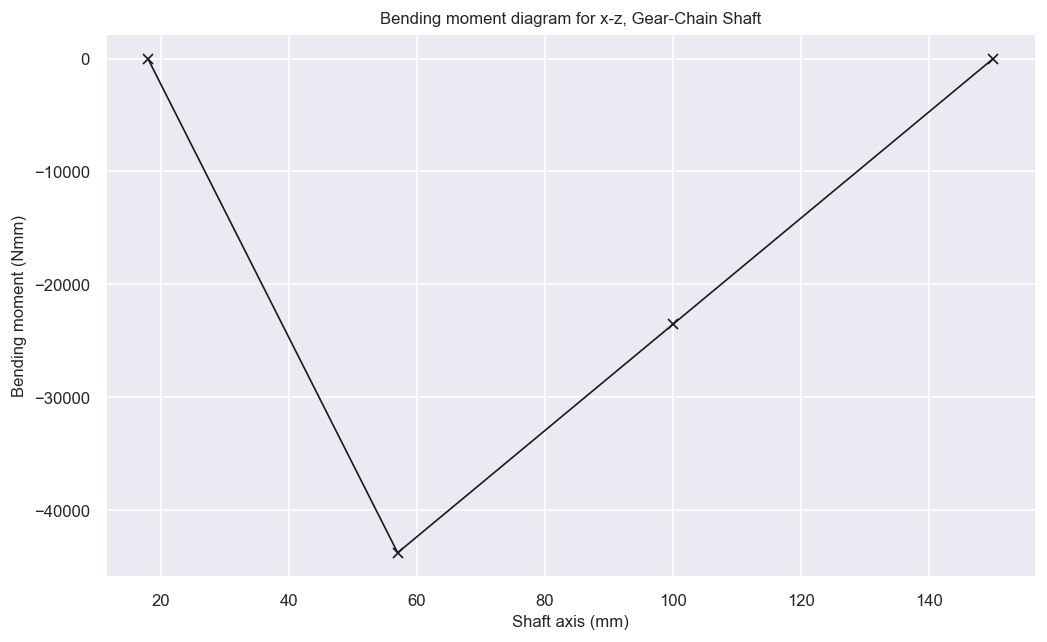

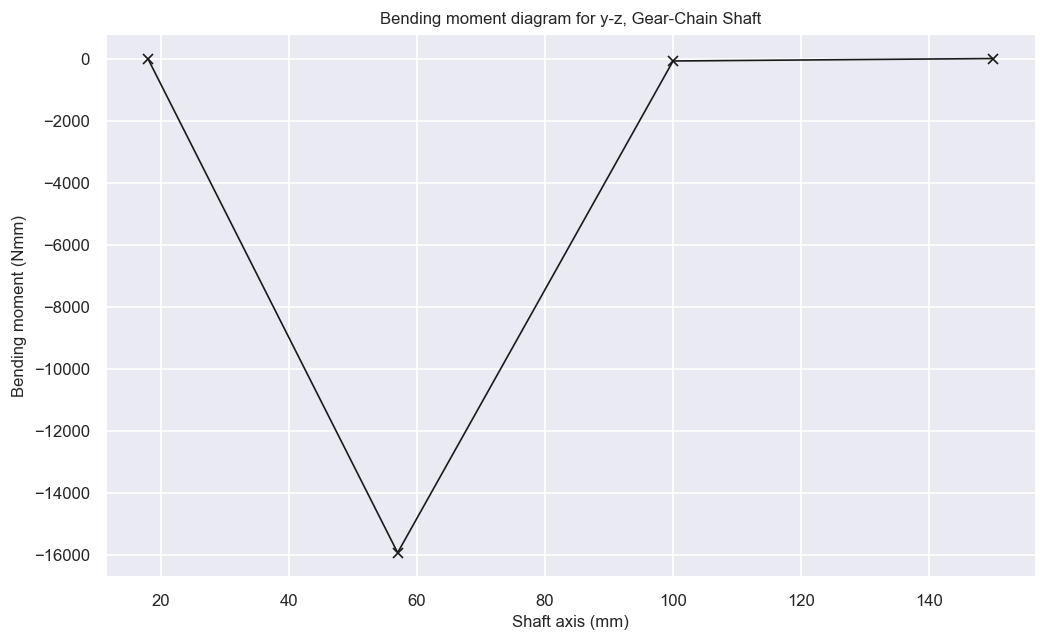

Net torque (in Nm) at	 Driving gear - Chain-Gear  = 	 43.66
Net torque (in Nm) at	 Bearing 6 - Chain-Gear  = 	 43.66
Net torque (in Nm) at	 Chain Driven Sprocket - Chain-Gear  = 	 43.66
Net torque (in Nm) at	 Bearing 5 - Chain-Gear  = 	 0


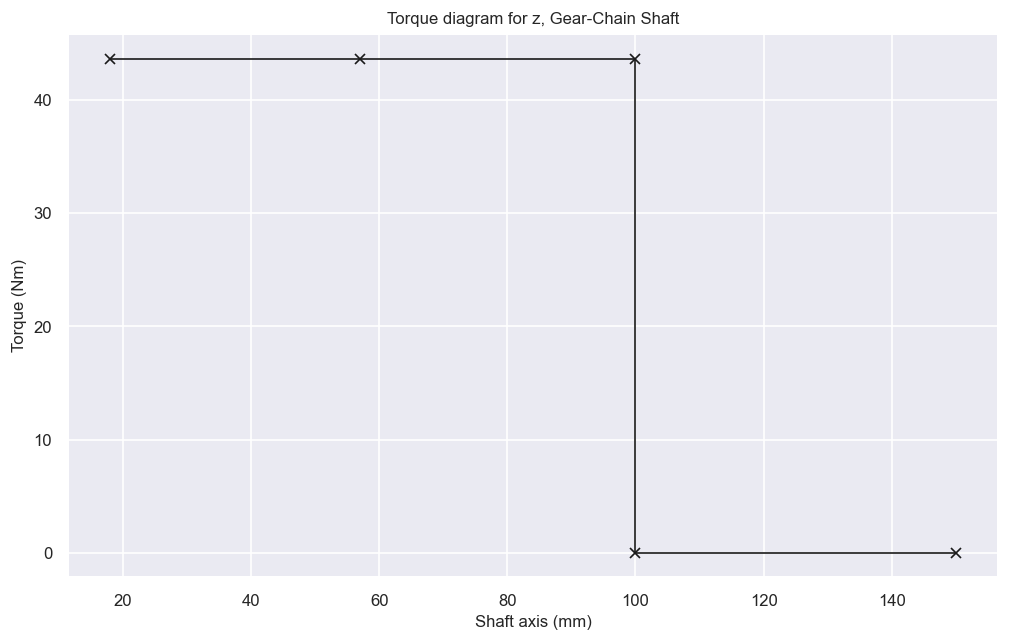

In [16]:
shaft_bmd([gear_driver, bearing6, chain_driven, bearing5], "Gear-Chain Shaft")

In [17]:
PrintShaftResults([gear_driver, bearing6, chain_driven, bearing5])

Minimum diameter in mm as per ASME design equations for Driving gear - Chain-Gear
Left point: 	  11.87487039606491  mm
Middle point: 	  11.87487039606491  mm
Right point: 	  11.87487039606491  mm
Minimum diameter in mm as per ASME design equations for Bearing 6 - Chain-Gear
Left point: 	  22.903554370455197  mm
Middle point: 	  19.992703468048433  mm
Right point: 	  22.903554370455165  mm
Minimum diameter in mm as per ASME design equations for Chain Driven Sprocket - Chain-Gear
Left point: 	  19.992574606600993  mm
Middle point: 	  17.545154293349746  mm
Right point: 	  19.992574606600964  mm
Minimum diameter in mm as per ASME design equations for Bearing 5 - Chain-Gear
Left point: 	  0.0  mm
Middle point: 	  0.0  mm
Right point: 	  0.0  mm


# Bottom Roller (Shaft 4)

In [70]:
bearing8 =  MachineElement( 
            torque_Nm = 33.47,           # Torque experienced by machine element
            moment_Nm = 0,                 # Moment experienced by machine element
            scf_l = 3,                    # Stress concentration of the immediate left element
            scf_m = 1,                    # Stress concentration of the element (middle)
            scf_r = 2.5,                    # Stress concentration of the immediate right element
            sy_MPa = 2000,                 # Yield strength
            su_MPa = 1730,                 # Ultimate strength
            sn_MPa = 440,                 # Endurance strength (nominal), actual endurance strength will be
                                          # automatically calculated as part of the class.
            initdia_mm = 30,              # Initial diameter for iteration with size factor. Size factor
                                          # is automatically calculated as part of the class.
            name_str = "Bearing 8 - Bottom Roller",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 0,                # Force in vertical direction, from the floor to the roller.
            x_mm = 4.0)                    # Relative position of element. x_mm = 0 for the left most.

gear3  =  MachineElement( 
            torque_Nm = 33.47,           # Torque experienced by machine element
            moment_Nm = 35.52695329390404,               # Moment experienced by machine element
            scf_l = 3,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 1.5,                   # Stress concentration of the immediate right element
            sy_MPa = 2000,               # Yield strength
            su_MPa = 1730,               # Ultimate strength
            sn_MPa = 440,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Gear 3 - Bottom Roller ",         
            Fx_N = 582.09,                 # Force parallel to the working surface
            Fy_N = 211.86,                # Force in vertical direction, from the floor to the roller.
            x_mm = 29)                    # Relative position of element. x_mm = 0 for the left most.



sugarcane_bottom =  MachineElement( 
            torque_Nm = 66.94,           # Torque experienced by machine element
            moment_Nm = 193.84476998003484,               # Moment experienced by machine element
            scf_l = 1,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 1,                   # Stress concentration of the immediate right element
            sy_MPa = 2000,               # Yield strength
            su_MPa = 1730,               # Ultimate strength
            sn_MPa = 440,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Sugarcane - Bottom Roller",         
            Fx_N = -620,                 # Force parallel to the working surface
            Fy_N = -3100,                # Force in vertical direction, from the floor to the roller.
            x_mm = 129)                    # Relative position of element. x_mm = 0 for the left most.

gear_driven =  MachineElement( 
            torque_Nm = 66.94,           # Torque experienced by machine element
            moment_Nm = 46.142560965535665,                 # Moment experienced by machine element
            scf_l = 1.5,                    # Stress concentration of the immediate left element
            scf_m = 1,                    # Stress concentration of the element (middle)
            scf_r = 3,                    # Stress concentration of the immediate right element
            sy_MPa = 2000,                 # Yield strength
            su_MPa = 1730,                 # Ultimate strength
            sn_MPa = 440,                 # Endurance strength (nominal), actual endurance strength will be
                                          # automatically calculated as part of the class.
            initdia_mm = 30,              # Initial diameter for iteration with size factor. Size factor
                                          # is automatically calculated as part of the class.
            name_str = "Driven Gear - Bottom Roller",         
            Fx_N = 1122,                 # Force parallel to the working surface
            Fy_N = 408.5,                # Force in vertical direction, from the floor to the roller.
            x_mm = 231.5)                    # Relative position of element. x_mm = 0 for the left most.

bearing7 =  MachineElement( 
            torque_Nm = 66.94,           # Torque experienced by machine element
            moment_Nm = 0,               # Moment experienced by machine element
            scf_l = 3,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 3,                   # Stress concentration of the immediate right element
            sy_MPa = 2000,               # Yield strength
            su_MPa = 1730,               # Ultimate strength
            sn_MPa = 440,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Bearing 7 - Bottom Roller",         
            Fx_N = 0,                 # Force parallel to the working surface
            Fy_N = 0,                # Force in vertical direction, from the floor to the roller.
            x_mm = 266.35)                    # Relative position of element. x_mm = 0 for the left most.


In [71]:
# The code will automatically solve and update the force in the y direction Fy_N 
# of the element with the solved force.
force_solver_1D(known_list = [gear3, sugarcane_bottom, gear_driven],    # Put elements with unknown forces here
                unknown_list = [bearing8, bearing7],         # Put elements with known forces here
                axis_str = "y")                              # State the axis of solution.

# The code will automatically solve and update the force in the y direction Fy_N 
# of the element with the solved force.
force_solver_1D(known_list = [gear3, sugarcane_bottom, gear_driven],    # Put elements with unknown forces here
                unknown_list = [bearing8, bearing7],       # Put elements with known forces here
                axis_str = "x")                            # State the axis of solution.

[Unknown force for first, unknown force for second] [1377.02993711 1102.61006289]
[Unknown force for first, unknown force for second] [-351.072085 -733.017915]


The bending moments in the x-axis are: 

[0, -8776.802125023823, 14324.989374880883, -25545.674337716788, 2.9103830456733704e-11]

The bending moments in the y-axis are: 

[0, 34425.74842767281, 193314.74213836403, 38425.960691822576, -1.5534169506281614e-09]

X-axis Force at  Bearing 8 - Bottom Roller  =  -351.07208500095294
X-axis Force at  Gear 3 - Bottom Roller   =  582.09
X-axis Force at  Sugarcane - Bottom Roller  =  -620
X-axis Force at  Driven Gear - Bottom Roller  =  1122
X-axis Force at  Bearing 7 - Bottom Roller  =  -733.017914999047

Y-axis Force at  Bearing 8 - Bottom Roller  =  1377.0299371069123
Y-axis Force at  Gear 3 - Bottom Roller   =  211.86
Y-axis Force at  Sugarcane - Bottom Roller  =  -3100
Y-axis Force at  Driven Gear - Bottom Roller  =  408.5
Y-axis Force at  Bearing 7 - Bottom Roller  =  1102.6100628930817

Net bending moment (in Nm) at  Bearing 8 - Bottom Roller  = 	 0.0
xz  bending moment (in Nm) at  Bearing 8 - Bottom Roller  = 	 0.0
yz  bending moment (in 

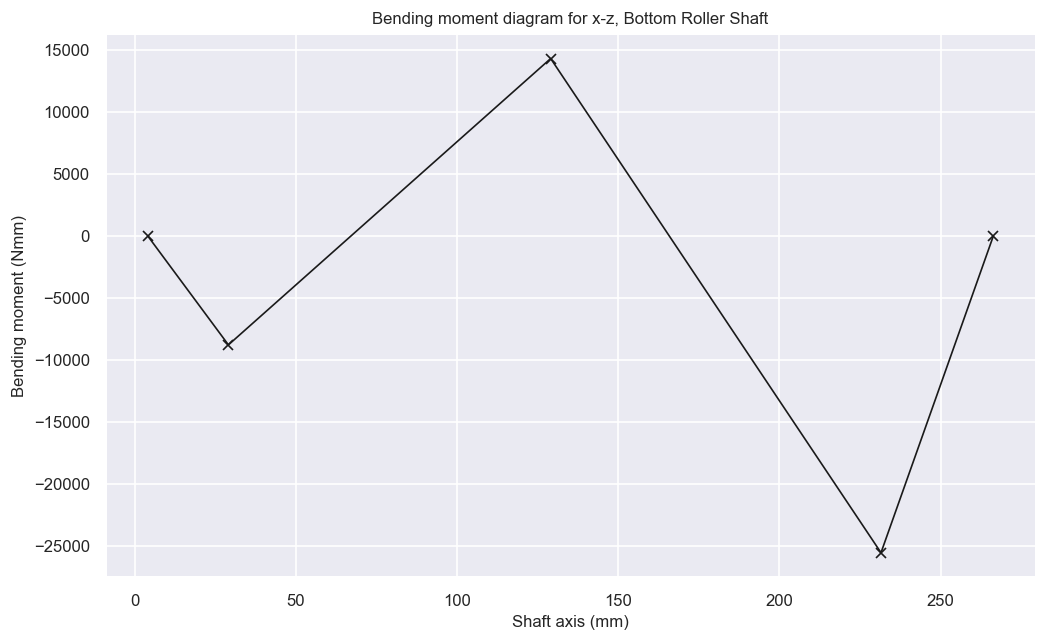

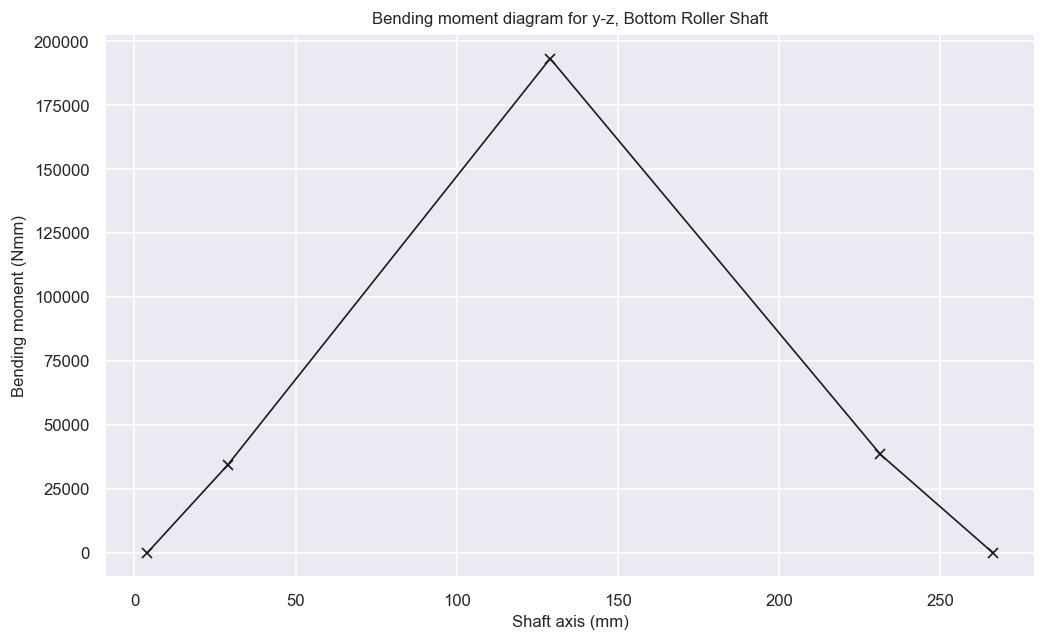

Net torque (in Nm) at	 Bearing 8 - Bottom Roller  = 	 33.47
Net torque (in Nm) at	 Gear 3 - Bottom Roller   = 	 33.47
Net torque (in Nm) at	 Sugarcane - Bottom Roller  = 	 66.94
Net torque (in Nm) at	 Driven Gear - Bottom Roller  = 	 66.94
Net torque (in Nm) at	 Bearing 7 - Bottom Roller  = 	 66.94


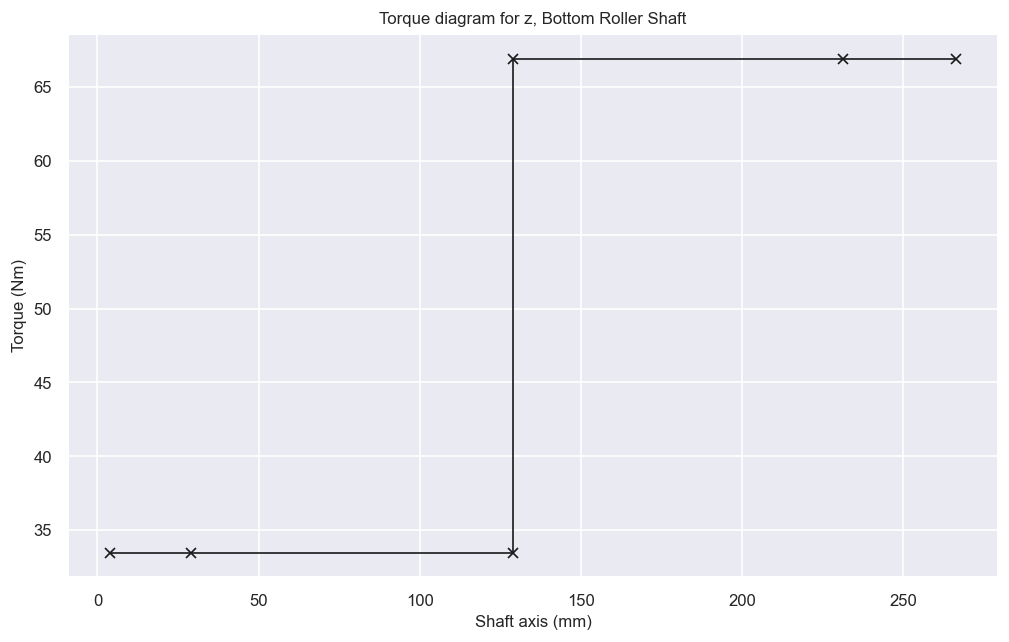

In [72]:
shaft_bmd([bearing8, gear3, sugarcane_bottom, gear_driven, bearing7], "Bottom Roller Shaft")

In [73]:
PrintShaftResults([bearing8, gear3, sugarcane_bottom, gear_driven, bearing7])

Minimum diameter in mm as per ASME design equations for Bearing 8 - Bottom Roller
Left point: 	  7.622414654004335  mm
Middle point: 	  7.622414654004335  mm
Right point: 	  7.622414654004335  mm
Minimum diameter in mm as per ASME design equations for Gear 3 - Bottom Roller 
Left point: 	  21.73259452062072  mm
Middle point: 	  14.901698168588279  mm
Right point: 	  17.11580840698045  mm
Minimum diameter in mm as per ASME design equations for Sugarcane - Bottom Roller
Left point: 	  26.73134478786108  mm
Middle point: 	  26.731344787861065  mm
Right point: 	  26.731344787861065  mm
Minimum diameter in mm as per ASME design equations for Driven Gear - Bottom Roller
Left point: 	  18.769719421543243  mm
Middle point: 	  16.378845620387484  mm
Right point: 	  23.8004446923326  mm
Minimum diameter in mm as per ASME design equations for Bearing 7 - Bottom Roller
Left point: 	  9.603640673607208  mm
Middle point: 	  9.603640673607208  mm
Right point: 	  9.603640673607208  mm


# Top Roller (Shaft 5)

In [56]:
bearing9 =  MachineElement( 
            torque_Nm = 33.47,           # Torque experienced by machine element
            moment_Nm = 0,                 # Moment experienced by machine element
            scf_l = 3,                    # Stress concentration of the immediate left element
            scf_m = 1,                    # Stress concentration of the element (middle)
            scf_r = 3,                    # Stress concentration of the immediate right element
            sy_MPa = 552,                 # Yield strength
            su_MPa = 490,                 # Ultimate strength
            sn_MPa = 210,                 # Endurance strength (nominal), actual endurance strength will be
                                          # automatically calculated as part of the class.
            initdia_mm = 30,              # Initial diameter for iteration with size factor. Size factor
                                          # is automatically calculated as part of the class.
            name_str = "Bearing 9 - Top Roller",         
            Fx_N = 0,                    # Force parallel to the working surface
            Fy_N = 0,                    # Force in vertical direction, from the floor to the roller.
            x_mm = 4)                 # Relative position of element. x_mm = 0 for the left most.

gear4  =  MachineElement( 
            torque_Nm = 33.47,           # Torque experienced by machine element
            moment_Nm = 35.2029045427626,               # Moment experienced by machine element
            scf_l = 3,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 1.5,                   # Stress concentration of the immediate right element
            sy_MPa = 2000,               # Yield strength
            su_MPa = 1730,               # Ultimate strength
            sn_MPa = 440,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Gear 4 - Top Roller",         
            Fx_N = 582.09,                 # Force parallel to the working surface
            Fy_N = -211.86,                # Force in vertical direction, from the floor to the roller.
            x_mm = 32.5)                    # Relative position of element. x_mm = 0 for the left most.


sugarcane_top =  MachineElement( 
            torque_Nm = 33.47,           # Torque experienced by machine element
            moment_Nm = 150.59132292394722,               # Moment experienced by machine element
            scf_l = 1,                   # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 1,                   # Stress concentration of the immediate right element
            sy_MPa = 2000,                # Yield strength
            su_MPa = 1730,                # Ultimate strength
            sn_MPa = 440,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Sugarcane - Top Roller",         
            Fx_N = -620,                 # Force parallel to the working surface
            Fy_N = 3100,                 # Force in vertical direction, from the floor to the roller.
            x_mm = 112.5)                # Relative position of element. x_mm = 0 for the left most.

bearing10 =  MachineElement( 
            torque_Nm = 0,           # Torque experienced by machine element
            moment_Nm = 0,               # Moment experienced by machine element
            scf_l = 1.5,                 # Stress concentration of the immediate left element
            scf_m = 1,                   # Stress concentration of the element (middle)
            scf_r = 3,                   # Stress concentration of the immediate right element
            sy_MPa = 2000,                # Yield strength
            su_MPa = 1730,               # Ultimate strength
            sn_MPa = 440,                # Endurance strength (nominal), actual endurance strength will be
                                         # automatically calculated as part of the class.
            initdia_mm = 30,             # Initial diameter for iteration with size factor. Size factor
                                         # is automatically calculated as part of the class.
            name_str = "Bearing 10 - Top Roller",         
            Fx_N = 0,                   # Force parallel to the working surface
            Fy_N = 0,                   # Force in vertical direction, from the floor to the roller.
            x_mm = 201.5)               # Relative position of element. x_mm = 0 for the left most.

In [57]:
# The code will automatically solve and update the force in the y direction Fy_N 
# of the element with the solved force.
force_solver_1D(known_list = [gear4, sugarcane_top],    # Put elements with unknown forces here
                unknown_list = [bearing9, bearing10],   # Put elements with known forces here
                axis_str = "y")                         # State the axis of solution.

# The code will automatically solve and update the force in the y direction Fy_N 
# of the element with the solved force.
force_solver_1D(known_list = [gear3, sugarcane_top],    # Put elements with unknown forces here
                unknown_list = [bearing9, bearing10],   # Put elements with known forces here
                axis_str = "x")                         # State the axis of solution.

[Unknown force for first, unknown force for second] [-1215.67422785 -1672.46577215]
[Unknown force for first, unknown force for second] [-218.69979747  256.60979747]


The bending moments in the x-axis are: 

[0, -6232.944227848104, 22838.27197468354, -1.4551915228366852e-11]

The bending moments in the y-axis are: 

[0, -34646.71549367115, -148849.45372152003, -1.862645149230957e-09]

X-axis Force at  Bearing 9 - Top Roller  =  -218.69979746835452
X-axis Force at  Gear 4 - Top Roller  =  582.09
X-axis Force at  Sugarcane - Top Roller  =  -620
X-axis Force at  Bearing 10 - Top Roller  =  256.60979746835443

Y-axis Force at  Bearing 9 - Top Roller  =  -1215.6742278481106
Y-axis Force at  Gear 4 - Top Roller  =  -211.86
Y-axis Force at  Sugarcane - Top Roller  =  3100
Y-axis Force at  Bearing 10 - Top Roller  =  -1672.4657721518986

Net bending moment (in Nm) at  Bearing 9 - Top Roller  = 	 0.0
xz  bending moment (in Nm) at  Bearing 9 - Top Roller  = 	 0.0
yz  bending moment (in Nm) at  Bearing 9 - Top Roller  = 	 0.0
Net bending moment (in Nm) at  Gear 4 - Top Roller  = 	 35.202904542762624
xz  bending moment (in Nm) at  Gear 4 - Top Roller  = 	 -6.23

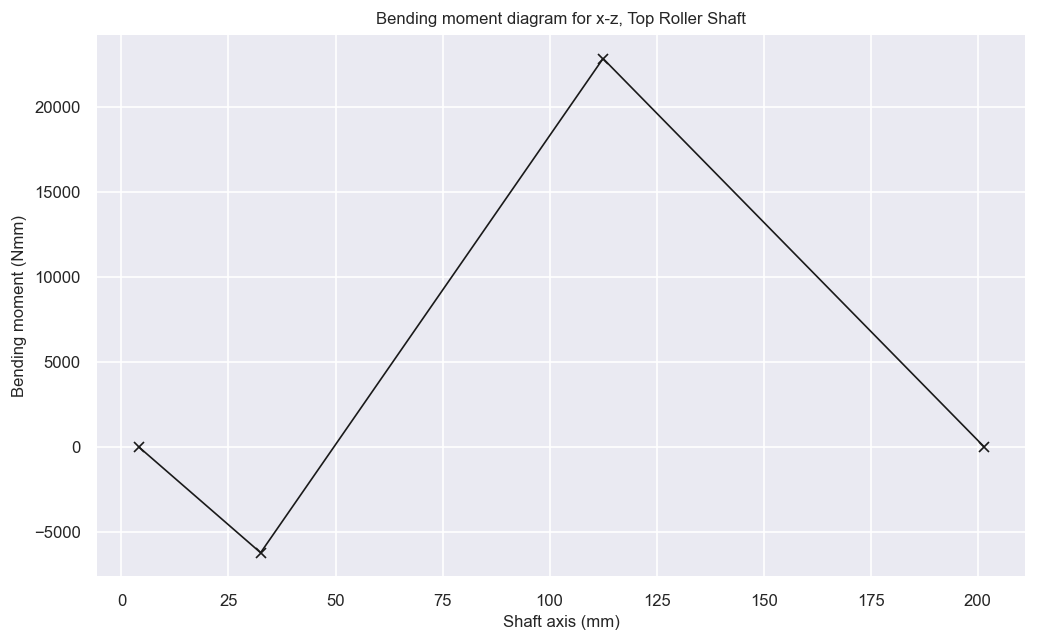

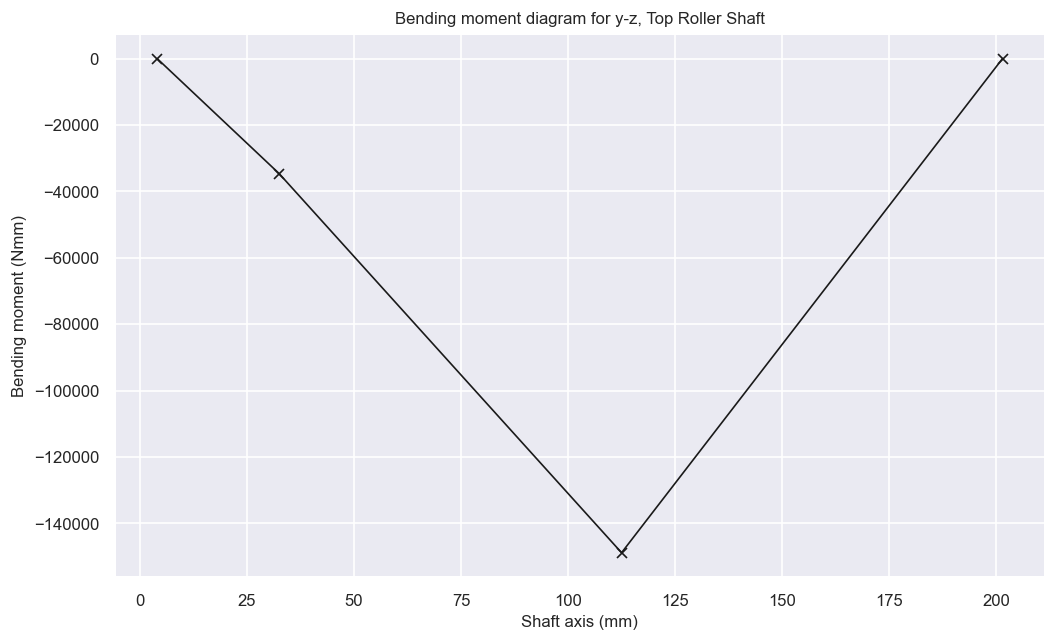

Net torque (in Nm) at	 Bearing 9 - Top Roller  = 	 33.47
Net torque (in Nm) at	 Gear 4 - Top Roller  = 	 33.47
Net torque (in Nm) at	 Sugarcane - Top Roller  = 	 33.47
Net torque (in Nm) at	 Bearing 10 - Top Roller  = 	 0


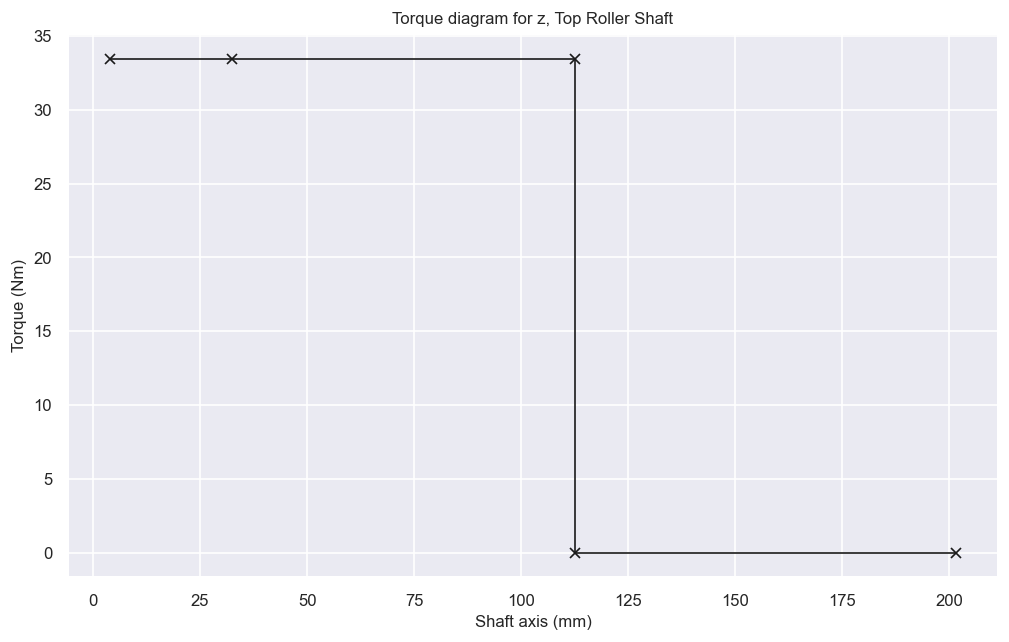

In [58]:
shaft_bmd([bearing9, gear4, sugarcane_top,  bearing10], "Top Roller Shaft")

In [59]:
PrintShaftResults([bearing9, gear4, sugarcane_top, bearing10])

Minimum diameter in mm as per ASME design equations for Bearing 9 - Top Roller
Left point: 	  11.707285507786715  mm
Middle point: 	  11.707285507786715  mm
Right point: 	  11.707285507786715  mm
Minimum diameter in mm as per ASME design equations for Gear 4 - Top Roller
Left point: 	  21.663932064978127  mm
Middle point: 	  14.855408889640344  mm
Right point: 	  17.062068918244975  mm
Minimum diameter in mm as per ASME design equations for Sugarcane - Top Roller
Left point: 	  24.48977549999475  mm
Middle point: 	  24.489775499994725  mm
Right point: 	  24.489775499994725  mm
Minimum diameter in mm as per ASME design equations for Bearing 10 - Top Roller
Left point: 	  0.0  mm
Middle point: 	  0.0  mm
Right point: 	  0.0  mm
